In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
filePath = 'btts_2plus_data.csv'
df = pd.read_csv(filePath)
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,...,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,RefereeAggression,EarlySeason,BTTS,Home_2plus,Away_2plus
0,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,...,0.523560,0.090000,0.994764,0.994764,0,0.0,0,1,1,1
1,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,5.0,...,0.523560,0.923077,0.994764,0.994764,0,0.0,0,0,0,0
2,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,4.0,...,0.523560,0.371111,0.994764,0.994764,0,0.0,0,1,0,0
3,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,9.0,...,0.523560,0.230769,0.994764,0.994764,0,0.0,0,0,0,0
4,1.0,1.0,D,0.0,0.0,D,C Foy,12.0,10.0,4.0,...,0.523560,1.428571,0.994764,0.994764,0,0.0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7896,3.0,2.0,H,2.0,1.0,H,S Attwell,19.0,9.0,7.0,...,0.425532,0.181333,0.668085,0.668085,1,5.0,0,1,1,1
7897,2.0,1.0,H,1.0,1.0,D,J Smith,15.0,13.0,4.0,...,0.480769,3.387097,0.831731,0.831731,1,3.0,0,1,1,0
7898,3.0,1.0,H,1.0,0.0,H,S Hooper,12.0,24.0,6.0,...,0.347222,0.437500,0.486111,0.486111,1,5.7,0,1,1,0
7899,4.0,2.0,H,0.0,0.0,D,A Taylor,34.0,5.0,15.0,...,0.370370,0.207143,0.533333,0.533333,0,4.7,1,1,1,1


              precision    recall  f1-score   support

           0       0.54      0.53      0.54       785
           1       0.54      0.55      0.55       796

    accuracy                           0.54      1581
   macro avg       0.54      0.54      0.54      1581
weighted avg       0.54      0.54      0.54      1581



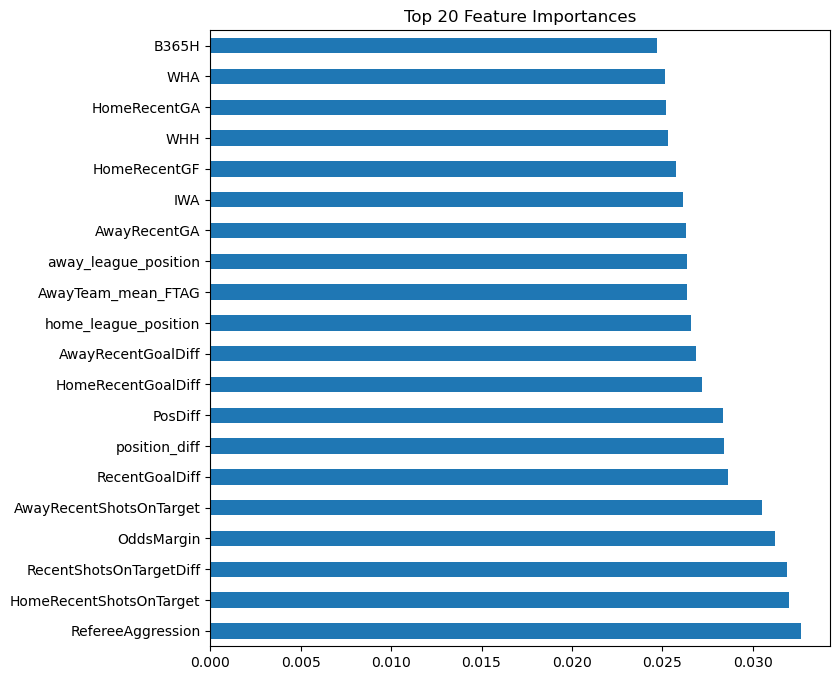

In [5]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Home_2plus', 'Away_2plus'
    ]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['GoalsOver2_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances')
plt.show()

In [6]:
print(feat_importances)

IWH                  0.023038
IWD                  0.020700
IWA                  0.026133
WHH                  0.025326
WHD                  0.021790
                       ...   
OU_OddsMargin        0.009186
OverUnderRatio       0.010042
Weekend              0.005185
RefereeAggression    0.032645
EarlySeason          0.004673
Length: 130, dtype: float64


In [7]:
feat_importances.to_string('feature_importances.txt')

              precision    recall  f1-score   support

           0       0.50      0.50      0.50       791
           1       0.50      0.50      0.50       790

    accuracy                           0.50      1581
   macro avg       0.50      0.50      0.50      1581
weighted avg       0.50      0.50      0.50      1581



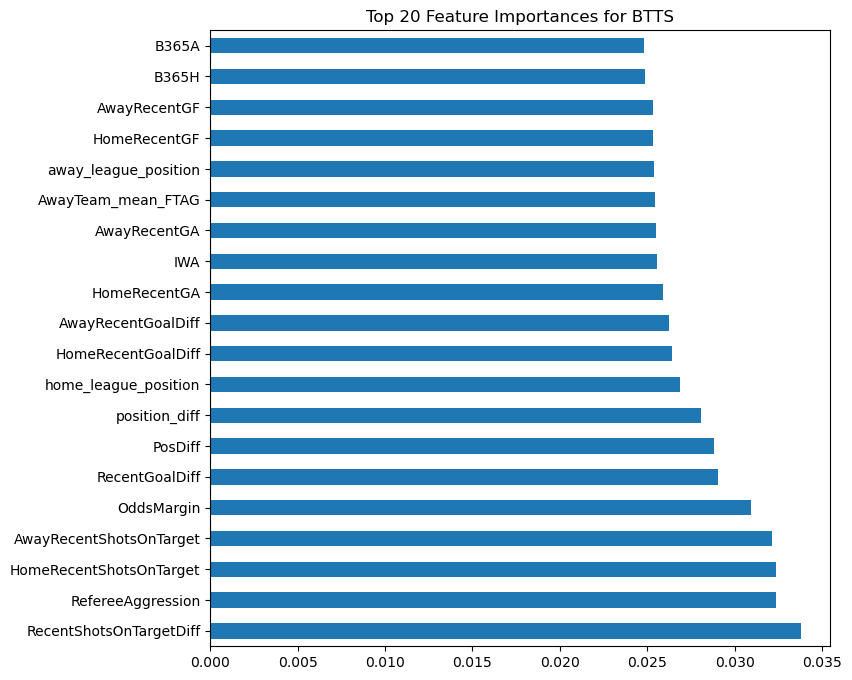

In [8]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Home_2plus', 'Away_2plus'
    ]

df['BTTS'] = ((df['FTHG'] > 0) & (df['FTAG'] > 0)).astype(int)

X = df.drop(columns=cols_to_drop + ['BTTS', 'Home_2plus', 'Away_2plus'], errors='ignore')
y = df['BTTS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances for BTTS')
plt.show()

              precision    recall  f1-score   support

           0       0.65      0.73      0.68       889
           1       0.58      0.49      0.53       692

    accuracy                           0.62      1581
   macro avg       0.61      0.61      0.61      1581
weighted avg       0.62      0.62      0.62      1581



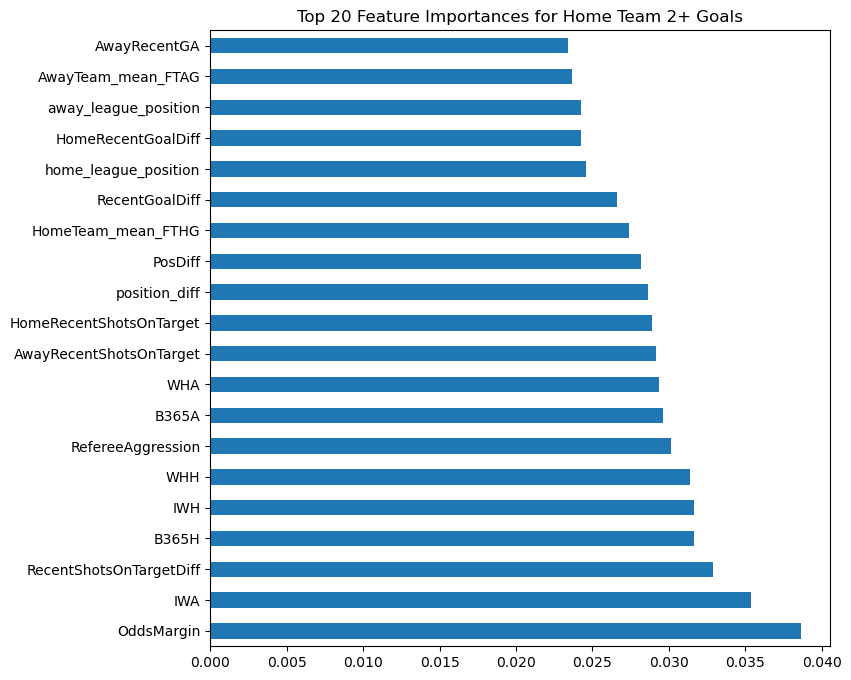

In [9]:
df['Home_2plus'] = (df['FTHG'] >= 2).astype(int)

X = df.drop(columns=cols_to_drop + ['BTTS', 'Home_2plus', 'Away_2plus'], errors='ignore')
y = df['Home_2plus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances for Home Team 2+ Goals')
plt.show()

              precision    recall  f1-score   support

           0       0.73      0.90      0.81      1085
           1       0.55      0.27      0.36       496

    accuracy                           0.70      1581
   macro avg       0.64      0.59      0.58      1581
weighted avg       0.67      0.70      0.67      1581



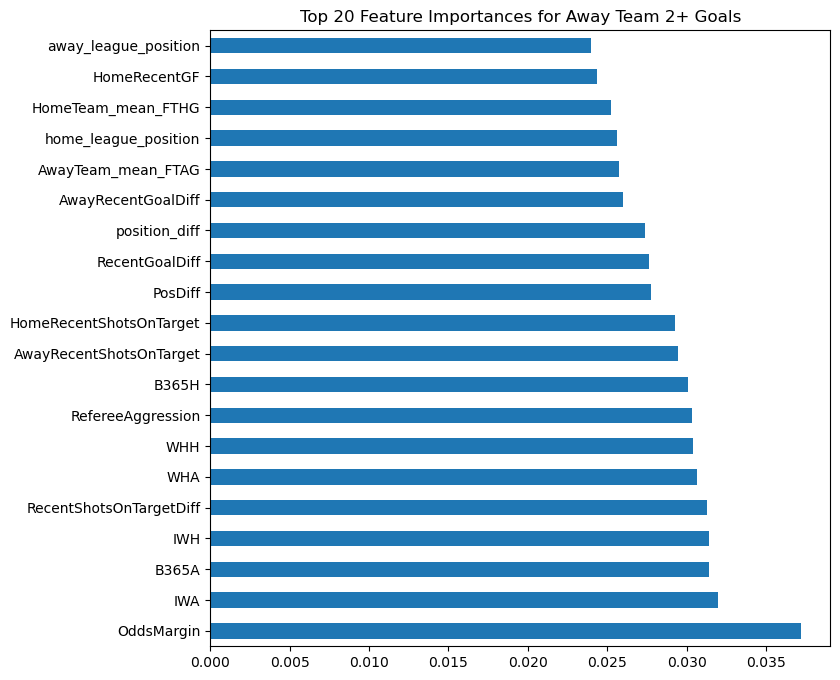

In [10]:
df['Away_2plus'] = (df['FTAG'] >= 2).astype(int)

X = df.drop(columns=cols_to_drop + ['BTTS', 'Home_2plus', 'Away_2plus'], errors='ignore')
y = df['Away_2plus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances for Away Team 2+ Goals')
plt.show()